# Gaussian states and gates

Objectives:  
1. Understand as a minimum equations (20) and (22) in Jonatan's reference, as well as those in gray boxes in section III. The covariance matrices and displacement vectors of the four classes of single-mode Gaussian states mentioned above are presented in section VI. We will not consider two-mode or multi-mode states in this exercise.
2. Create functions for calculating the Wigner function of a general Gaussian state.
3. Using contour plot, 3D surface plot, or similar, plot the Wigner functions of various single-mode Gaussian states based on the formulas indicated above.\
Don't spend too much time on optimising the visuals of the plots in this exercise - you can go with the defaults, if you wish. But decide on a fixed visual style that you will maintain for all your plots.
4. Now, try out `interact` and/or `FuncAnimation` for varying parameters of your state plots (for example the coherent state amplitude or the degree of squeezing).
5. Write functions for performing Gaussian operations on your Gaussian states: displacement, phase shift and squeezing.
6. Your overall task is now to write a notebook, introducing Gaussian states and operations to your fellow students in a narrative style with text mixed with code and visualisations. The focus here should be on the physics and the visual explanation of it, not so much on discussing the code.
7. At the end of the day, share your notebook – however incomplete – on Discord.

## 1. Undstanding the equations
The reference is available in [Jonathan's reference](https://arxiv.org/pdf/2102.05748).

### 1.1 Equaitons (20) and (22)
$$
\begin{align}
    W(\vec{r}) &= \dfrac{1}{(2\pi)^n\sqrt{\det(\bm{\sigma})}}e^{-\frac{1}{2}(\vec{r}-\bar{r})^T\bm{\sigma}^{-1}(\vec{r}-\bar{r})} \tag{20} \\

    \bm{\sigma} \rightarrow \bm{F}\bm{\sigma}\bm{F}^T, \quad &\mathrm{and}, \quad \vec{r} \rightarrow \bm{F}\vec{r} + \vec{d} \tag{22}
\end{align}
$$

Eq. (20) has the form of the multivariate normal distribution, a gaussian in 2 or more dimensions (see the wiki-page: [multivariate normal distrubition](https://en.wikipedia.org/wiki/Multivariate_normal_distribution#Density_function)).  
<!-- It is implicit that $\vec{r} = (\vec{x},\vec{p})$, which in turn  -->
The bar, $\bar{r}$, indicates the mean position and sigma, $\sigma$, is the covariance-matrix (How the probability varies align one dimension in relation to another).
The paramters $n$ is the dimensionality of the vector $\vec{r} \in \mathbb{R}^n$ and the matrix $\bm{\sigma} \in \mathbb{R}^{n\times n}$

- NOTE: The difference in the exponent for $(2\pi)$ between Jonathan's reference and the Wiki definition, is due to $\vec{r} = (\vec{x},\vec{p})$ being implicit, and if each has $n$ demensions, the total is then $2n$, and where the term usually is represented in the squareroot, it can be factored out as shown above.

---
Eq. (22) explains how a guassian (unitary) transformation changes the covariance matrix and the displacement vector, $(\bm{\sigma},\vec{r})$

### 1.2 Some relevant equations in section III. Gaussian Unitaries

#### Displacement operation
$$\begin{align}
    \bm{F} &= \mathbb{I}_{2n} \tag{28} \\
    \vec{d} &= \sqrt{2}\begin{pmatrix} \mathrm{Re}(\alpha_1) \\ \mathrm{Im}(\alpha_1) \\ \vdots \\ \mathrm{Re}(\alpha_n) \\ \mathrm{Im}(\alpha_n)\end{pmatrix} \tag{29}
\end{align}$$
For a displacement of $\vec{\alpha}$

- This means that a displacement operator on the Wigner function does not alter the covariance matrix, but shifts the $\vec{r}$ as shown above.

#### Phase shift operation
$$\begin{align}
    \bm{F} &=
        \begin{pmatrix}
            \cos(\phi) & \sin(\phi) \\
            -\sin(\phi) & \cos(\phi) 
        \end{pmatrix} \equiv \bm{R}(\phi) \tag{33} \\

    \vec{d} &= \vec{0}
\end{align}$$

A phase shift of a Wigner function correpsonds to a rotation of the covariance matrix, and leaves the displacement unchanged.

#### Beam splitter
$$\begin{align}
    \bm{F} &= 
        \begin{bmatrix} 
        \sqrt{\eta}\ \mathbb{I}_{2} & \sqrt{1-\eta}\ \mathbb{I}_{2} \\
        \sqrt{1-\eta}\ \mathbb{I}_{2} & \sqrt{\eta}\ \mathbb{I}_{2} 
        \end{bmatrix} \equiv \bm{F}_{\eta} \tag{41} \\
        \vec{d} &= \vec{0} \tag{42}
\end{align}$$
Using a beamsplitter leaves the displacement at zero, and mixes the mode operators (shown is the two-mode beam-splitter).  
$\eta$ is the transmitivity.

## 2. Create class for generating Wigner functions for Gaussian states

In [36]:
import numpy as np
from functools import reduce


class Wigner():
    """Wigner function for a Gaussian distribution in phase space."""
    
    def __init__(self, mean, sigma):
        """
        Initialize the Wigner function with mean and covariance matrix.
        
        Parameters
        -----------
        mean (ndarray[K, N]) : Mean vector of the Gaussian distribution. Can be a 1D or 2D array.
            - If 1D, it is treated as a single point in K-dimensional space.  
            - If 2D, each row corresponds to a point in K-dimensional space.  
            - K is the number of points and N is the dimensionality of the mean vector.  
            - The mean vector should be of shape (N,) or (K, N).  
        
        
        sigma (ndarray[N, N]) : Covariance matrix of the Gaussian distribution. It should be a square matrix of shape (N, N) where N is the dimensionality of the mean vector.
        """
        
        self.state = {
            'mean': None,
            'cov': None,
        }
        self.mean = mean
        self.sigma = sigma
        
        self.dim = len(self.mean)
        self.__setattr__("mean", mean)
        self.__setattr__("cov", sigma)
        
        self.sigmaDet = np.linalg.det(self.sigma)
        self.sigmaInv = np.linalg.inv(self.sigma)
        self.norm = 1/((2*np.pi)**self.dim * np.sqrt(self.sigmaDet))
        
            
    def __call__(self, r, kwargs=None):
        """
        Evaluate the Wigner function at points r.
        
        Parameters
        -----------
        r (ndarray[N, K]) : Points in phase space where the Wigner function is evaluated. Each row corresponds to a point in K-dimensional space.
        kwargs (dict) : Optional dictionary to update the state of the Wigner function. It can contain 'mean' or 'cov' to update the mean vector or covariance matrix respectively.
        Returns
        --------
        ndarray : Values of the Wigner function at the points r.
        """
        if kwargs is not None:
            if np.any(["mean", "cov"]) in kwargs:
                if "mean" in kwargs:
                    self.mean = kwargs["mean"]
                if "cov" in kwargs:
                    self.sigma = kwargs["cov"]
            else:
                raise ValueError("kwargs must contain 'mean' or 'cov' to update the state.")
        
        r = np.atleast_2d(r) # Ensure r is at least 2D
        assert r.shape[-1] == self.mean.shape[0], "Each input point must match mean's shape"
        diff = r - self.mean
        
        exponent = -0.5 * np.einsum("ni,ij,nj->n...", diff , self.sigmaInv , diff)
        # exponent = -0.5 * diff.T @ self.sigmaInv @ diff
        
        return self.norm * np.exp(exponent)



def test_input(size):
    I = np.eye(size)
    sigma = I / np.linalg.norm(I)
    r = np.zeros((size, ))
    return r, sigma

rbar, sigma = test_input(2) # Example input for a 2D Gaussian distribution

wigner = Wigner(rbar, sigma) # Initialize the Wigner function with mean and covariance matrix

# test the Wigner function on a grid of points in phase space
x = np.linspace(-5, 5, 100)
p = np.linspace(-5, 5, 100)
X, P = np.meshgrid(x, p)
grid_points = np.vstack([X.ravel(), P.ravel()]).T

# calculate the Wigner function for the grid points
wigner_values = wigner(grid_points).reshape(X.shape)
print("mean :\n{:}\n\ncov :\n{:}".format(wigner.mean, wigner.sigma))
print()
with np.printoptions(formatter={"float": lambda x: f"{x:>4.2f}"}, linewidth=110):
    print("Wigner function values:\n{:}".format(wigner_values[40:60, 40:60]))

mean :
[0. 0.]

cov :
[[0.70710678 0.        ]
 [0.         0.70710678]]

Wigner function values:
[[0.01 0.01 0.01 0.01 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.01 0.01 0.01 0.01]
 [0.01 0.01 0.01 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.01 0.01 0.01]
 [0.01 0.01 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.01 0.01]
 [0.01 0.02 0.02 0.02 0.02 0.02 0.02 0.03 0.03 0.03 0.03 0.03 0.03 0.02 0.02 0.02 0.02 0.02 0.02 0.01]
 [0.02 0.02 0.02 0.02 0.02 0.02 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.02 0.02 0.02 0.02 0.02 0.02]
 [0.02 0.02 0.02 0.02 0.02 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.02 0.02 0.02 0.02 0.02]
 [0.02 0.02 0.02 0.02 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.02 0.02 0.02 0.02]
 [0.02 0.02 0.02 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.02 0.02 0.02]
 [0.02 0.02 0.02 0.03 0.03 0.03 0.03 0.03 0.03 0.04 0.04 0.03 0.03 0.03 0.03 0

### 2.1 Plotting the Wigner function

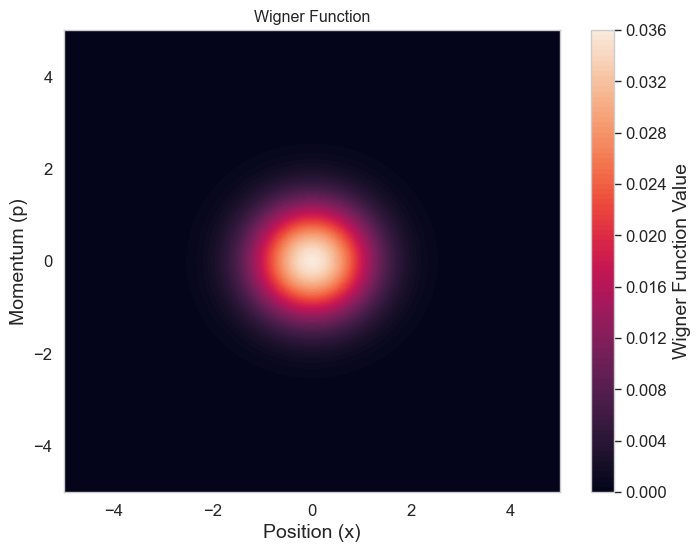

In [ ]:
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
import seaborn as sns
# Set seaborn style for the plot
rc_params = {
    "figure.figsize": (6, 5),
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
}
sns.set_theme(context="paper", style="whitegrid",
              font_scale=1.2,
              font='sans-serif',
                rc=rc_params
                )


fig, ax = plt.subplots(figsize=(8, 6))
plot = ax.contourf(X, P, wigner_values.reshape(X.shape), levels=100,
        #   cmap='viridis',
          )

ax.set_xlabel('Position (x)')
ax.set_ylabel('Momentum (p)')
ax.set_title('Wigner Function')
plt.colorbar(plot, ax=ax, label='Wigner Function Value')
plt.show()

### 2.2 Plotting Wigner function for different covariance matrices

In [ ]:
# plotting for different covariance matrices

covariances = {
    "Vacuum (0.5 I)": 0.5 * np.eye(2),
    "Squeezed x": np.array([[0.2, 0.0], [0.0, 1.25]]),
    "Squeezed p": np.array([[1.25, 0.0], [0.0, 0.2]]),
    "Correlated": np.array([[0.5, 0.4], [0.4, 0.5]]),
    "Thermal (1.0 I)": 1.0 * np.eye(2),
}

def plot_wigner(cov_name):
    mean = np.zeros(2)
    cov = covariances.get(cov_name, None)
    if cov is None:
        if cov_name.lower() == "vacuum":    cov = covariances["Vacuum (0.5 I)"]
        elif cov_name.lower() == "x":       cov = covariances["Squeezed x"]
        elif cov_name.lower() == "p":       cov = covariances["Squeezed p"]
        elif cov_name.lower() == "thermal": cov = covariances["Thermal (1.0 I)"]
        elif cov_name.lower() == "corr":    cov = covariances["Correlated"]
    
    wigner = Wigner(mean, cov)

    x = np.linspace(-3, 3, 100)
    p = np.linspace(-3, 3, 100)
    X, P = np.meshgrid(x, p)
    points = np.stack([X.ravel(), P.ravel()], axis=1)

    W = wigner(points).reshape(100, 100)

    plt.figure(figsize=(6,5))
    plt.contourf(X, P, W, levels=100)
    plt.xlabel('$X$')
    plt.ylabel('$P$')
    plt.title(f"Wigner Function: {cov_name}")
    plt.colorbar()
    plt.show()

interact(plot_wigner, cov_name=widgets.Dropdown(options=list(covariances.keys()), description='Covariance'))



interactive(children=(Dropdown(description='Covariance', options=('Vacuum (0.5 I)', 'Squeezed x', 'Squeezed p'…

<function __main__.plot_wigner(cov_name)>